In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')

print(train_df.head())
print(test_df.head())

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  
   Class Index                                              Title  \
0            3                  Fears for T N pension after talks   
1            4  The Race is On: Second Private Team Sets Launc...   
2            4      Ky. Company Wins Grant to St

In [44]:
train_df.rename(columns={"Class Index": "label"}, inplace=True)
test_df.rename(columns={"Class Index": "label"}, inplace=True)


In [45]:
print(train_df.head())
train_df.columns

   label                                              Title  \
0      3  Wall St. Bears Claw Back Into the Black (Reuters)   
1      3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2      3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3      3  Iraq Halts Oil Exports from Main Southern Pipe...   
4      3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


Index(['label', 'Title', 'Description'], dtype='str')

In [46]:
train_df['text']=train_df['Title'] + " " + train_df['Description']
test_df['text']=test_df['Title'] + " " + test_df['Description']

train_df["label"] = train_df["label"] - 1
test_df["label"] = test_df["label"] - 1

In [47]:
print("Training Set Shape:", train_df.shape)
print("Test Set Shape:", test_df.shape)

train_df.info()

Training Set Shape: (120000, 4)
Test Set Shape: (7600, 4)
<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   label        120000 non-null  int64
 1   Title        120000 non-null  str  
 2   Description  120000 non-null  str  
 3   text         120000 non-null  str  
dtypes: int64(1), str(3)
memory usage: 57.7 MB


In [48]:
train_df.isnull().sum()
test_df.isnull().sum()

train_df["label"].value_counts().sort_index()

label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64

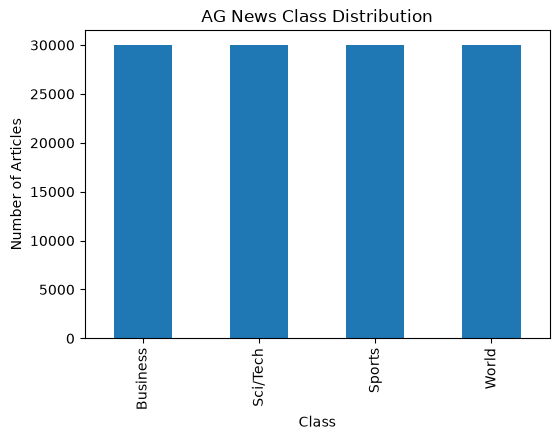

In [49]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

train_df["label"].map(label_names).value_counts()

import matplotlib.pyplot as plt

train_df["label"].map(label_names).value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("AG News Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Articles")
plt.show()

In [50]:
train_df["word_count"] = train_df["text"].apply(
    lambda x: len(x.split())
)

train_df["word_count"].describe()

count    120000.000000
mean         37.844617
std          10.088702
min           4.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: word_count, dtype: float64

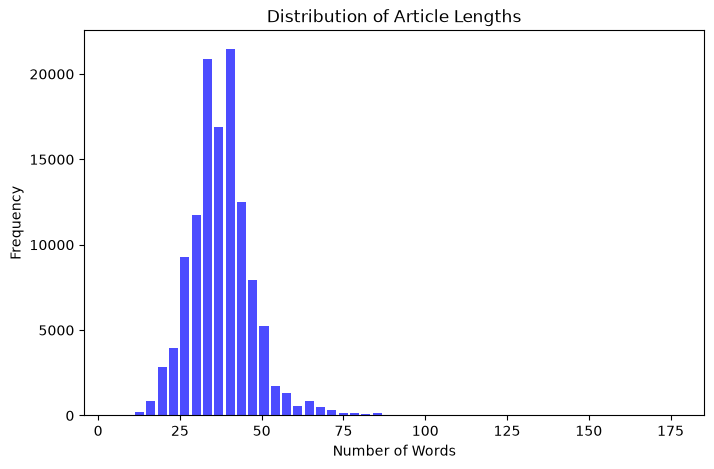

In [51]:
plt.figure(figsize=(8,5))

plt.hist(train_df["word_count"], bins=50, rwidth=0.8, color='blue', alpha=0.7)

plt.title("Distribution of Article Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [52]:
print("Shortest Article:")
print(train_df.loc[train_df["word_count"].idxmin(), "text"])

print("\n")

print("Longest Article:")
print(train_df.loc[train_df["word_count"].idxmax(), "text"])

Shortest Article:
Top of 3rd #NAME?


Longest Article:
2004 US Senate Outlook With all the hoopla over Bush and Kerry, some of you may not have been paying close attention to the other races going on in this loaded US political season. I've read a good dozen or so Senate outlooks, and my blurry eyes and spinning brain kept getting lost in all the numbers and losing track of who, ultimately, was likely to control the Senate on November third. So I made my very own Senate outlook to figure it out (or add further confusion, depending on what you think of my predictions). The bad news is, we probably won't know who controls the Senate on November third. The good news, if you're a Democrat (or a person who loves one), is that my best guess at this point is that when the dust settles, Democrats will probably be in control by the very slimmest possible margin. Shock! But everyone knows the Dems have no chance of taking either house of Congress. I think everyone hasn't been paying attention. R

In [53]:
for i in range(3):
    print("="*100)
    # label_names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
    print("Label :", label_names[train_df.iloc[i]["label"]])
    print("Title :", train_df.iloc[i]["Title"])
    print("Description :", train_df.iloc[i]["Description"])

Label : Business
Title : Wall St. Bears Claw Back Into the Black (Reuters)
Description : Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label : Business
Title : Carlyle Looks Toward Commercial Aerospace (Reuters)
Description : Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Label : Business
Title : Oil and Economy Cloud Stocks' Outlook (Reuters)
Description : Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.


In [54]:
import re
import string

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)




In [55]:
for i in range(3):
    print("="*100)
    print("Original:")
    print(train_df["text"].iloc[i])

    print("\nCleaned:")
    print(train_df["clean_text"].iloc[i])

Original:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Cleaned:
wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again
Original:
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.

Cleaned:
carlyle looks toward commercial aerospace reuters reuters private investment firm carlyle groupwhich has a reputation for making welltimed and occasionallycontroversial plays in the defense industry has quietly placedits bets on another part of the market
Original:
Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expect

In [56]:
X_train = train_df["clean_text"]
y_train = train_df["label"]

X_test = test_df["clean_text"]
y_test = test_df["label"]


from sklearn.feature_extraction.text import TfidfVectorizer


# tdidf vectorization is a technique that transforms text data into numerical vectors based on the importance of words in the documents. It helps in capturing the significance of words while reducing the impact of frequently occurring words that may not carry much meaning.
# it works by calculating the term frequency (TF) of each word in a document and the inverse document frequency (IDF) across all documents. The TF-IDF score for each word is then computed by multiplying its TF and IDF values. This results in a vector representation of the text, where each dimension corresponds to a unique word in the vocabulary, and the values represent the importance of those words in the context of the documents.
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [57]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(120000, 10000)
(7600, 10000)


In [58]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])

['00' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '100' '1000'
 '10000' '100000' '100m' '100meter' '100th' '101' '102']


In [59]:
import pandas as pd

first_doc = X_train_tfidf[0].toarray().flatten()

tfidf_df = pd.DataFrame({
    "word": feature_names,
    "score": first_doc
})

tfidf_df = tfidf_df[tfidf_df["score"] > 0]
tfidf_df.sort_values("score", ascending=False).head(10)

,word,score
9665,wall,0.533515
7922,seeing,0.373110
1081,bears,0.337847
8614,streets,0.334386
7495,reuters,0.308866
1208,black,0.304424
3962,green,0.297328
8477,st,0.271512


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

model_logre = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_NB=MultinomialNB()
model_linearsvc= LinearSVC()
model_logre.fit(X_train_tfidf, y_train)
model_NB.fit(X_train_tfidf,y_train)
model_linearsvc.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [61]:

y_pred_logre =model_logre.predict(X_test_tfidf)

y_pred_NB=model_NB.predict(X_test_tfidf)

y_pred_linearsvc= model_linearsvc.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score

accuracy_logre=accuracy_score(y_test, y_pred_logre)

accuracy_NB= accuracy_score(y_test,y_pred_NB)

accuracy_linearsvc = accuracy_score(y_test,y_pred_linearsvc)



print(f"Accuracy_logre: {accuracy_logre:.4f}")

print (f"Accuracy_NB:{accuracy_NB:.4f}")

print(f"Accuracy_linearsvc : {accuracy_linearsvc:.4f}")
       

Accuracy_logre: 0.9126
Accuracy_NB:0.8967
Accuracy_linearsvc : 0.9126


In [62]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_logre,
    target_names=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
))

print(classification_report(
    y_test,
    y_pred_NB,
    target_names=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
))

print(classification_report(
    y_test,
    y_pred_linearsvc,
    target_names=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
))

              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.88      0.88      0.88      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600

              precision    recall  f1-score   support

       World       0.91      0.89      0.90      1900
      Sports       0.94      0.98      0.96      1900
    Business       0.87      0.85      0.86      1900
    Sci/Tech       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600

              precision    recall  f1-score   support

       World       0.93      0.90      0.92      1900
      Sports       0.

[[1723   53   73   51]
 [  22 1863    9    6]
 [  62   16 1666  156]
 [  49   23  144 1684]]


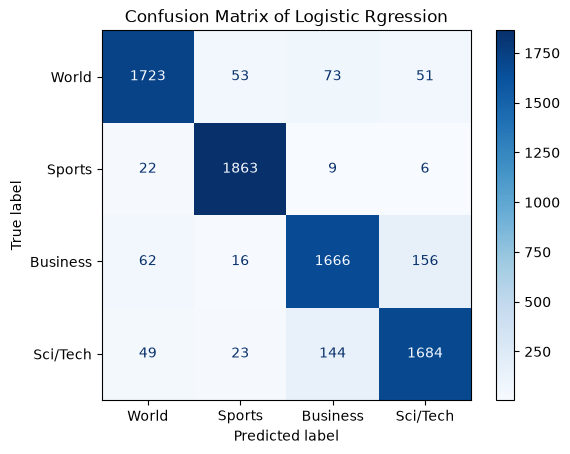

[[1723   53   73   51]
 [  22 1863    9    6]
 [  62   16 1666  156]
 [  49   23  144 1684]]


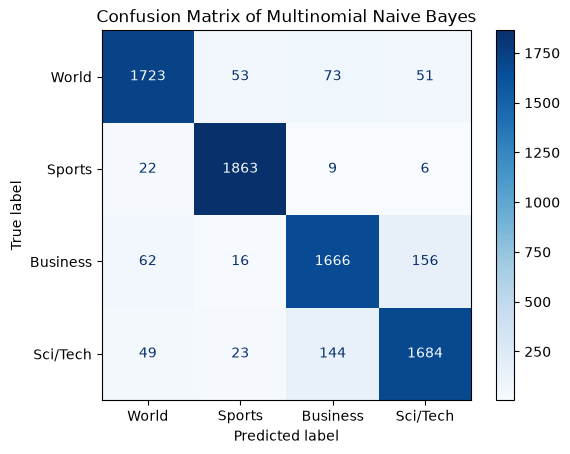

[[1723   53   73   51]
 [  22 1863    9    6]
 [  62   16 1666  156]
 [  49   23  144 1684]]


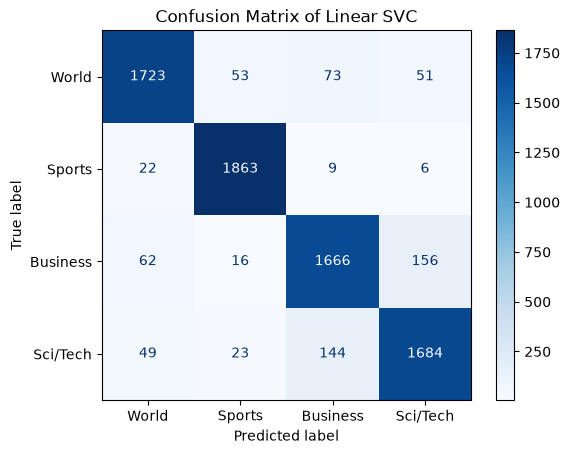

In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_logre)

print(cm)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix of Logistic Rgression")
plt.show()

cm_NB = confusion_matrix(y_test, y_pred_logre)

print(cm_NB)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_NB,
    display_labels=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix of Multinomial Naive Bayes")
plt.show()

cm_linearsvc= confusion_matrix(y_test, y_pred_logre)

print(cm_linearsvc)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_linearsvc,
    display_labels=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix of Linear SVC")
plt.show()